# Generate images and videos with MuJoCo

This notebook shows how to use MuJoCo and RobotBlockSet rendering utilities to create still images and video sequences from a simulated industrial inspection scenario.

It demonstrates how to:

- load prior robot motion and inspection trajectory data
- initialize a MuJoCo scene and robot model
- resample the trajectory for smooth frame generation
- render multiple fixed camera views
- generate preview videos from each view
- compose a combined multi-view video
- create a moving camera that tracks the robot tool

This tutorial is about visualization rather than motion planning. For collision-free trajectory generation, see the tutorial **tutorial_generation_collision-free_trajectories**.


## Imports

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from time import sleep, time
from copy import copy
import mediapy as media
from pathlib import Path

import mujoco
from robotblockset.mujoco.tools_pymujoco import check_path_for_collisions, make_free_camera, check_collisions, get_joints_under_body
from robotblockset.tools import get_rbs_path
from robotblockset.transformations import map_pose, rot_x, rot_y, rot_z, rp2t, frame2world
from robotblockset.mujoco.tools_pymujoco import get_robot_joints_data, get_geoms_of_body, get_body_descendants
from robotblockset.mujoco.tools_pymujoco import min_body_env_distance, min_robot_env_distance
from robotblockset.trajectories import interpPath, interpCartesianPath

from robotblockset.mujoco.scene_pymujoco_sim import mujoco_scene
from robotblockset.mujoco.robots_pymujoco_sim import ur10e

np.set_printoptions(precision=3, suppress=True, linewidth=100)

This notebook imports MuJoCo, RobotBlockSet scene and robot helpers, interpolation tools for trajectory resampling, and media utilities for showing or saving rendered images and videos.


## Initialization

Define the MuJoCo model path and the rendering resolution used for both image capture and video generation.


In [2]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/"
HEIGHT = 960
WIDTH  = 1280

Load previously generated motion and inspection trajectory data from saved Matlab files. The loaded arrays include start/goal joint poses, waypoints, the planned path, and full state trajectories.


In [3]:
mat = scipy.io.loadmat(f"{get_rbs_path()}/tutorials/assets/inspection_path.mat")
q_start    = mat.get("q_start").flatten()
q_goal     = mat.get("q_goal").flatten()
waypts     = mat.get("waypts")
cv2_path       = mat.get("path")
T          = mat.get("T").flatten()
path_rq    = mat.get("path_rq")
path_rqd   = mat.get("path_rqd")
path_rqdd  = mat.get("path_rqdd")

In [4]:
mat = scipy.io.loadmat(f"{get_rbs_path()}/tutorials/assets/inspection_results.mat")
tt   = mat.get("tt").flatten()
qt   = mat.get("qt")
qdt  = mat.get("qdt")
xt   = mat.get("xt")
vt   = mat.get("vt")
rxt  = mat.get("rxt")
rvt  = mat.get("rvt")
rqt  = mat.get("rqt")
rqdt = mat.get("rqdt")
mt   = mat.get("mt").flatten()

## Prepare scene

Create the MuJoCo scene, initialize the robot, and configure environment geometry groups so the rendered output highlights the important inspection objects.


### Load scene

Open the MuJoCo simulation and load the inspection environment model from **inspection_scene.xml**. The viewer is disabled here because rendering is performed programmatically.

In [5]:
scene = mujoco_scene(MODEL_PATH + "inspection_scene.xml", show_viewer=False)

### Initialize robot

Create the UR10e robot instance in the loaded scene, reset it to the first keyframe, and move it to the starting joint pose before rendering begins.

In [6]:
rs = ur10e(scene=scene)
rs.Restart(keyframe=0)
rs.JMove(q_start)

[RBS_INFO] [04:24:25.549] [ur10e_PyMuJoCo]: Robot connected to MuJoCo


0

### Close the gripper

Apply auxiliary control to close the robot gripper and ensure the robot remains in the desired start configuration.

In [7]:
rs.SendAuxCtrl([6], [160])
rs.JMove(q_start)

0

### Get necessary environment geometry data

Collect the camera-stand bodies and their geoms so they can be assigned a separate render group. This allows selective visibility or styling for different views.


In [8]:
bodies = get_body_descendants(scene.model, "camera2_stand", include_self=True)
geoms = get_geoms_of_body(scene.model, bodies)
for g in geoms:
    scene.model.geom(g).group = 5

### Interpolate data for image and video generation

Resample the recorded trajectory at a uniform time step suitable for smooth video playback. Also compute the tool pose in world coordinates for the moving camera tracking example.


In [9]:
t_video = np.arange(0.0, tt[-1], 0.04)
q_video = interpPath(tt, qt, t_video)
rxtw = frame2world(rxt, rs.TBase)
x_robot = interpCartesianPath(tt, rxtw, t_video)
samples = [10, 15, 20, 30, 40, 50, 60]

### Prepare rendering utilities for motion-overlay images

Set up MuJoCo visualization options for overlaying multiple robot poses in the same frame. This lets us render a semi-transparent ghosted motion trail together with a single highlighted pose.


In [10]:
model = scene.model
jnt, _ = get_joints_under_body(scene.model, "ur10e")
qaddr, _ = get_robot_joints_data(scene.model, jnt[:6])

# Visual options for the "ghost" robots.
vopt1 = mujoco.MjvOption()

vopt2 = mujoco.MjvOption()
vopt2.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = True  # Transparent.
pert = mujoco.MjvPerturb()  # Empty MjvPerturb object
# We only want dynamic objects. Static objects (the floor)
# should not be re-drawn. The mjtCatBit flag lets us do that, though we could
# equivalently use mjtVisFlag.mjVIS_STATIC
catmask = mujoco.mjtCatBit.mjCAT_DYNAMIC

## Image and video generation

Each subsection below configures a camera view, captures a preview image, and then generates a video sequence from the interpolated robot trajectory.


### View 1

Render the first fixed camera view with one panel emphasized. This section also builds a ghosted still image and generates a preview video showing the robot motion from this angle.


""

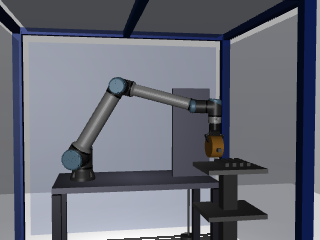

In [11]:
scene.model.geom("panel_right").group = 5
scene.model.geom("panel_left").group = 4
scene.model.geom("panel_front").group = 4
cam = make_free_camera(rs.scene.model, azimuth=-190, elevation=-2, distance=3.0, lookat=[0, 0.2, 1.2], fovy=35)
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
frame = scene.mj_capture_camera(camera=cam, scene_option=scene_option)
media.show_image(frame)

""

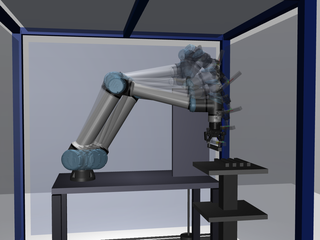

In [12]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_right_side_view.png", pixels)

In [13]:
frames = []
for q in q_video:
    rs.Restart(qpos=q, u=q, reset=False)
    frame = scene.mj_capture_camera(camera=cam, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames.append(frame)
media.show_video(frames, fps=25, width=320, height=240)
# media.write_video("inspection_right_side_view.mp4", frames, fps=25)

This browser does not support the video tag.


### View 2

Render a second fixed view from the front side. This camera offers a different perspective on the robot and inspection panels.


""

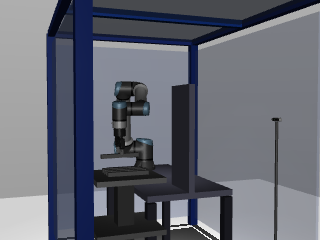

In [14]:
scene.model.geom("panel_right").group = 4
scene.model.geom("panel_left").group = 4
scene.model.geom("panel_front").group = 5
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
cam1 = make_free_camera(rs.scene.model, azimuth=-110, elevation=-2, distance=3.0, lookat=[0,0,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam1, scene_option=scene_option)
media.show_image(frame)

""

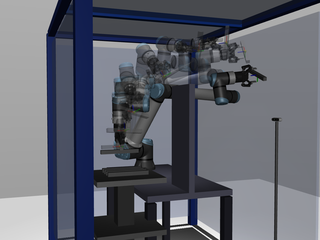

In [15]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam1, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_front_view.png", pixels)

### View 3

Render a third fixed view from another side angle. This provides an alternate visual reference for the same planned robot motion.


""

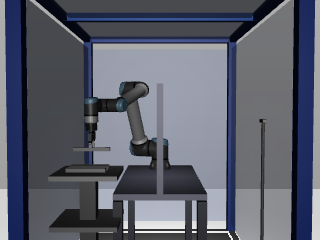

In [16]:
cam2 = make_free_camera(rs.scene.model, azimuth=-90, elevation=-2, distance=3.0, lookat=[0,0,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam2, scene_option=scene_option)
media.show_image(frame)

""

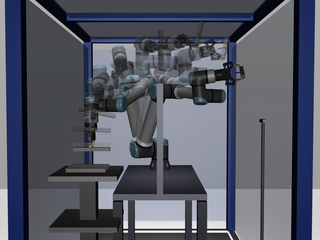

In [17]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam2, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_front_view1.png", pixels)

In [18]:
frames2 = []
for q in q_video:
    rs.Restart(qpos=q, u=q, reset=False)
    frame = scene.mj_capture_camera(camera=cam2, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames2.append(frame)
media.show_video(frames2, fps=25, width=320, height=240)
# media.write_video("inspection_front_view.mp4", frames2, fps=25)

This browser does not support the video tag.


### View 4

Render a fourth fixed viewpoint from the opposite side. This completes the set of static inspection angles used for multi-view comparison.


""

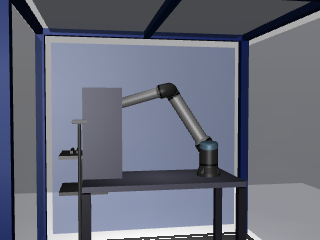

In [19]:
scene.model.geom("panel_right").group = 4
scene.model.geom("panel_left").group = 5
scene.model.geom("panel_front").group = 4
cam3 = make_free_camera(rs.scene.model, azimuth=-10, elevation=-2, distance=3.0, lookat=[0,0,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam3, scene_option=scene_option)
media.show_image(frame)

""

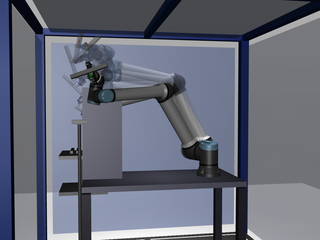

In [20]:
with mujoco.Renderer(model, height=HEIGHT, width=WIDTH) as renderer:
    rs.Restart(qpos=q_start, u=q_start, reset=False)
    data = copy(scene.data)
    renderer.update_scene(data, camera=cam3, scene_option=scene_option)
    
    _data = copy(scene.data)
    qq = _data.qpos.copy()
    for isamp in samples:
        for i, adr in enumerate(qaddr):
            qq[adr] = q_video[isamp, i]
        _data.qpos[:] = qq
        mujoco.mj_forward(model, _data)
        mujoco.mjv_addGeoms(model, _data, vopt2, pert, catmask, renderer.scene)

    for i, adr in enumerate(qaddr):
        qq[adr] = q_video[70, i]
    _data.qpos[:] = qq
    mujoco.mj_forward(model, _data)
    mujoco.mjv_addGeoms(model, _data, vopt1, pert, catmask, renderer.scene)

    #   # Render and add the frame.
    pixels = renderer.render()
    frames.append(pixels)

# Render video at half real-time.
media.show_image(pixels, width=320, height=240)
# media.write_image("inspection_left_side_view.png", pixels)

In [21]:
frames3 = []
for q in q_video:
    rs.Restart(qpos=q, u=q, reset=False)
    frame = scene.mj_capture_camera(camera=cam3, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames3.append(frame)
media.show_video(frames3, fps=25, width=320, height=240)
# media.write_video("inspection_left_side_view.mp4", frames3, fps=25)

This browser does not support the video tag.


### Make a combined video

Concatenate the videos from the three static viewpoints side by side to create one multi-view playback. This is useful for comparing how the same trajectory appears from multiple angles.


In [22]:
stacked_frames = [
    np.concatenate((f1, f2, f3), axis=1)
    for f1, f2, f3 in zip(frames, frames2, frames3)
]
media.show_video(stacked_frames, fps=25, width=320*3, height=240)
# media.write_video("inspection_all_views.mp4", stacked_frames, fps=25)

This browser does not support the video tag.


### Moving camera view tracking tool

Create a dynamic camera view whose look-at point follows the robot tool. The resulting video simulates a tracking camera that follows the inspection task.


""

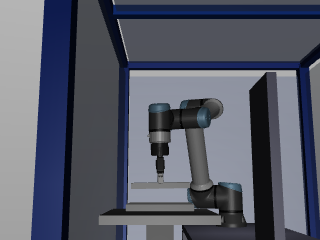

In [23]:
scene.model.geom("panel_right").group = 4
scene.model.geom("panel_left").group = 4
scene.model.geom("panel_front").group = 5
cam4 = make_free_camera(rs.scene.model, azimuth=-90, elevation=10, distance=1.2, lookat=[0.45,0.9,1.2], fovy=35)
frame = scene.mj_capture_camera(camera=cam4, scene_option=scene_option)
media.show_image(frame)

In [24]:
frames4 = []
for i, q in enumerate(q_video):
    rs.Restart(qpos=q, u=q, reset=False)
    cam4.lookat = x_robot[i, :3]
    frame = scene.mj_capture_camera(camera=cam4, height=HEIGHT, width=WIDTH, scene_option=scene_option)
    frames4.append(frame)
media.show_video(frames4, fps=25, width=320, height=240)
# media.write_video("inspection_track_view.mp4", frames4, fps=25)

This browser does not support the video tag.


## Project path into camera frame

Render a reference camera frame from the right-side view so we can overlay projected path information.

""

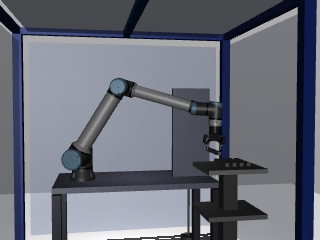

In [25]:
HEIGHT = 240
WIDTH = 320
scene.model.geom("panel_right").group = 5
scene.model.geom("panel_left").group = 4
scene.model.geom("panel_front").group = 4
cam = make_free_camera(rs.scene.model, azimuth=-190, elevation=-2, distance=3.0, lookat=[0, 0.2, 1.2], fovy=35)
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
frame = scene.mj_capture_camera(camera=cam, scene_option=scene_option, height=HEIGHT, width=WIDTH)

media.show_image(frame, height=HEIGHT, width=WIDTH)

In [26]:
import cv2
from robotblockset.mujoco.tools_pymujoco import project_to_camera_view, compute_camera_matrix_from_free_camera

Compute the camera projection matrix from the free camera parameters so 3D points can be projected into the image.

In [27]:
cm = compute_camera_matrix_from_free_camera(cam, model, height=HEIGHT, width=WIDTH)

Project the line from the robot base to the tool center point into the rendered frame and draw it on the captured image for spatial context.

""

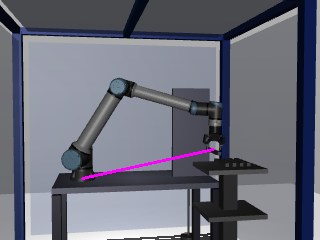

In [28]:
pts =np.vstack((rs.TBase[:3,3], rs.p))
pts_proj = project_to_camera_view(pts, cm)

frame_with_line = frame.copy()
cv2_path = pts_proj.T.astype(np.int32).reshape(-1, 1, 2)
tmp = cv2.polylines(frame_with_line, [cv2_path], isClosed=False, color=(255, 0, 255), thickness=2)
media.show_image(frame_with_line)